In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("train_energy_data.csv")
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


Our target column is energy consumption\
We are in supervised learning because we have target column\
Target column is continuous so we will use regression

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB


In [4]:
df.describe() #numeric only

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [5]:
df.describe(include='object') #categorical only

,Building Type,Day of Week
count,1000,1000
unique,3,2
top,Residential,Weekday
freq,347,507


In [6]:
df.isnull().sum()

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

No null values

In [7]:
df.duplicated().sum()

np.int64(0)

No duplicated values

#### EDA

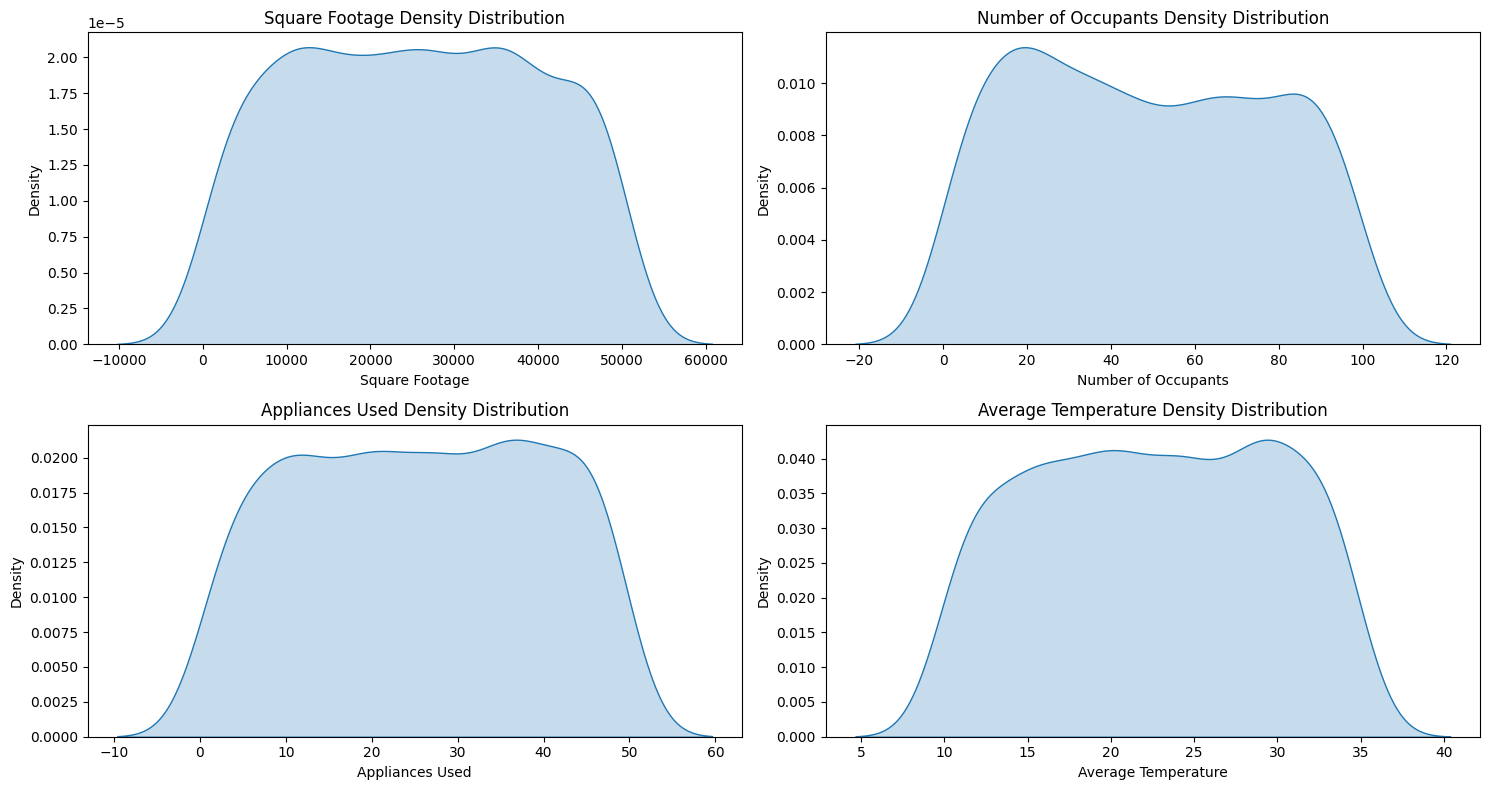

In [8]:
numeric=['Square Footage','Number of Occupants','Appliances Used','Average Temperature']
plt.figure(figsize=(15,8))
i=1
for val in numeric:
    plt.subplot(2,2,i)
    sns.kdeplot(df[val],fill=True)
    plt.xlabel(val)
    plt.ylabel("Density")
    plt.title(f"{val} Density Distribution")
    i+=1
plt.tight_layout()
plt.show()

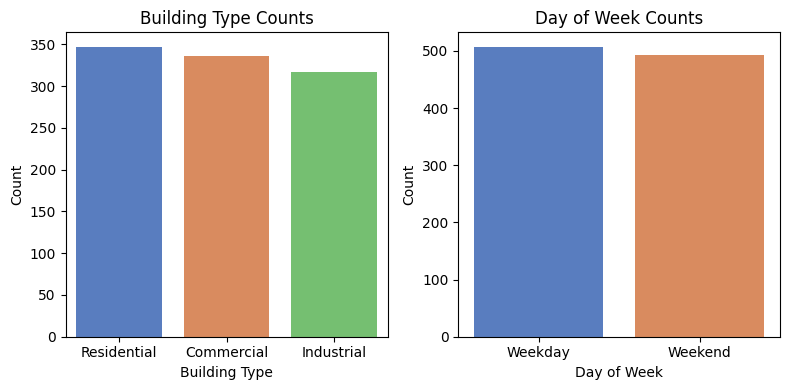

In [9]:
categorical=['Building Type','Day of Week']
plt.figure(figsize=(8,4))
i=1
for val in categorical:
    plt.subplot(1,2,i)
    sns.countplot(x=df[val],palette='muted')
    plt.xlabel(val)
    plt.ylabel("Count")
    plt.title(f"{val} Counts")
    i+=1
plt.tight_layout()
plt.show()

Target Column

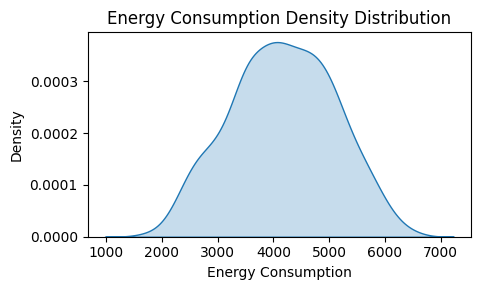

In [10]:
target='Energy Consumption'
plt.figure(figsize=(5,3))
sns.kdeplot(df[target],fill=True)
plt.xlabel(target)
plt.ylabel("Density")
plt.title(f"{target} Density Distribution")
plt.tight_layout()
plt.show()

Features vs Target Plots

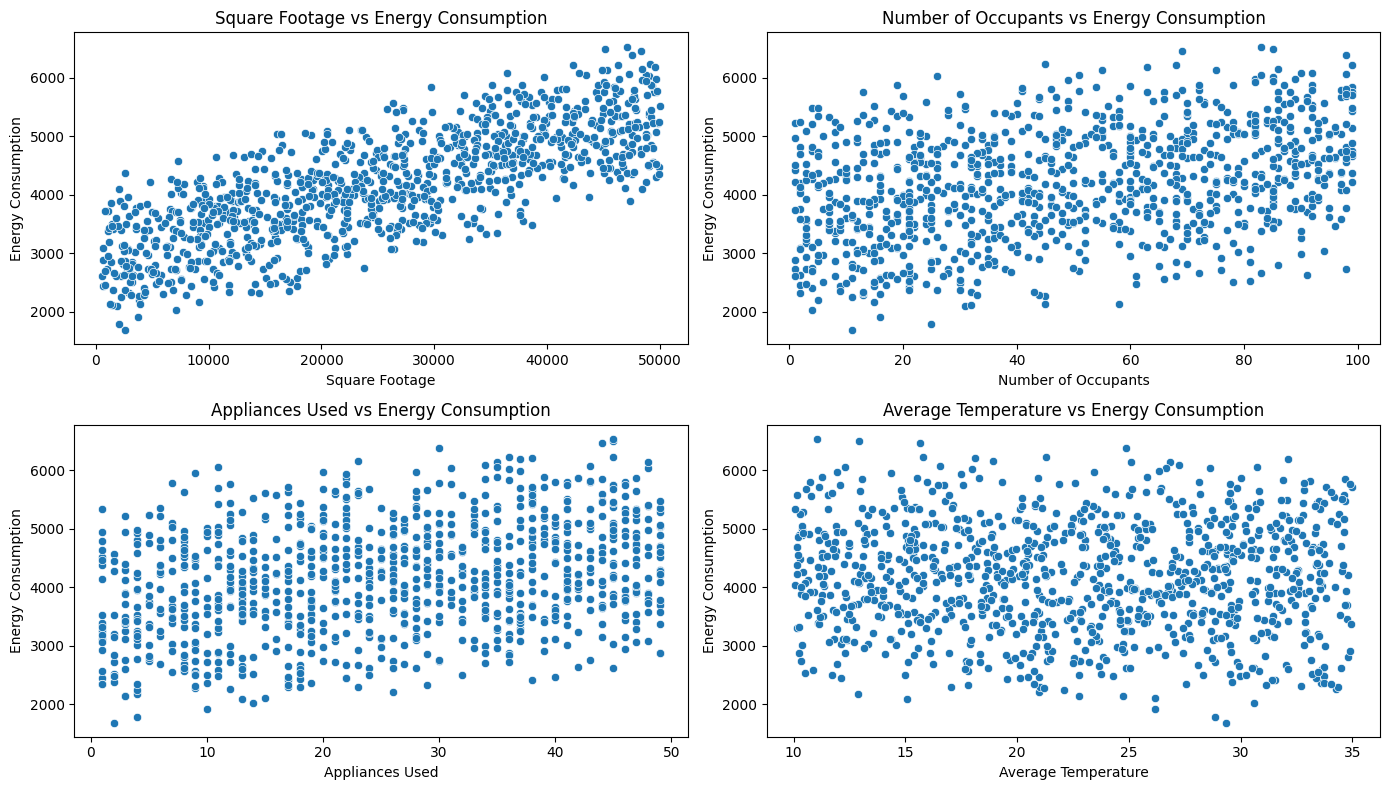

In [11]:
plt.figure(figsize=(14,8))
target='Energy Consumption'
i=1
for val in numeric:
    plt.subplot(2,2,i)
    sns.scatterplot(data=df,x=val,y=target)
    plt.xlabel(val)
    plt.ylabel(target)
    plt.title(f"{val} vs {target}")
    i+=1
plt.tight_layout()
plt.show()

Correlation Heatmap

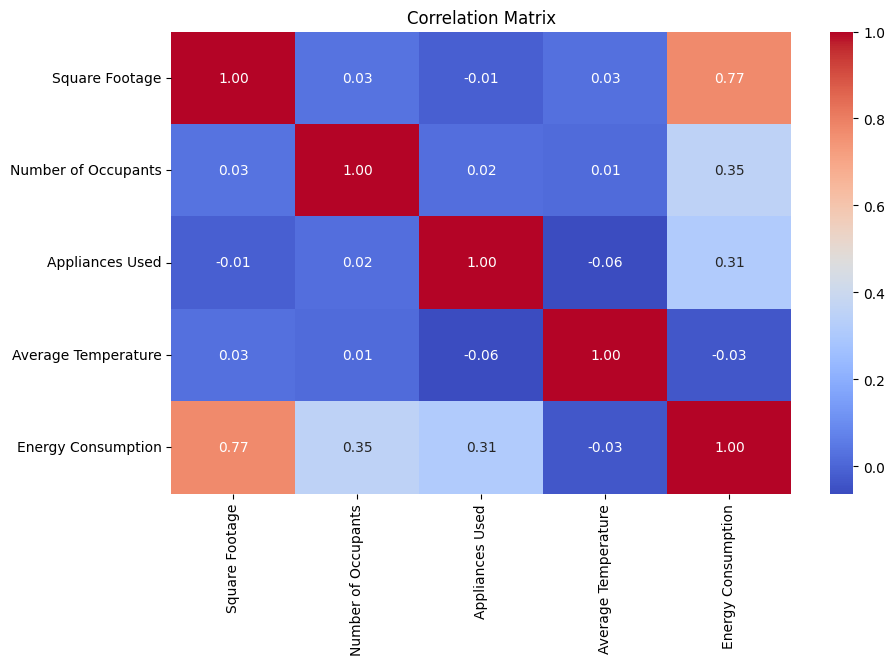

In [12]:
plt.figure(figsize=(10,6))
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

Checking for outliers

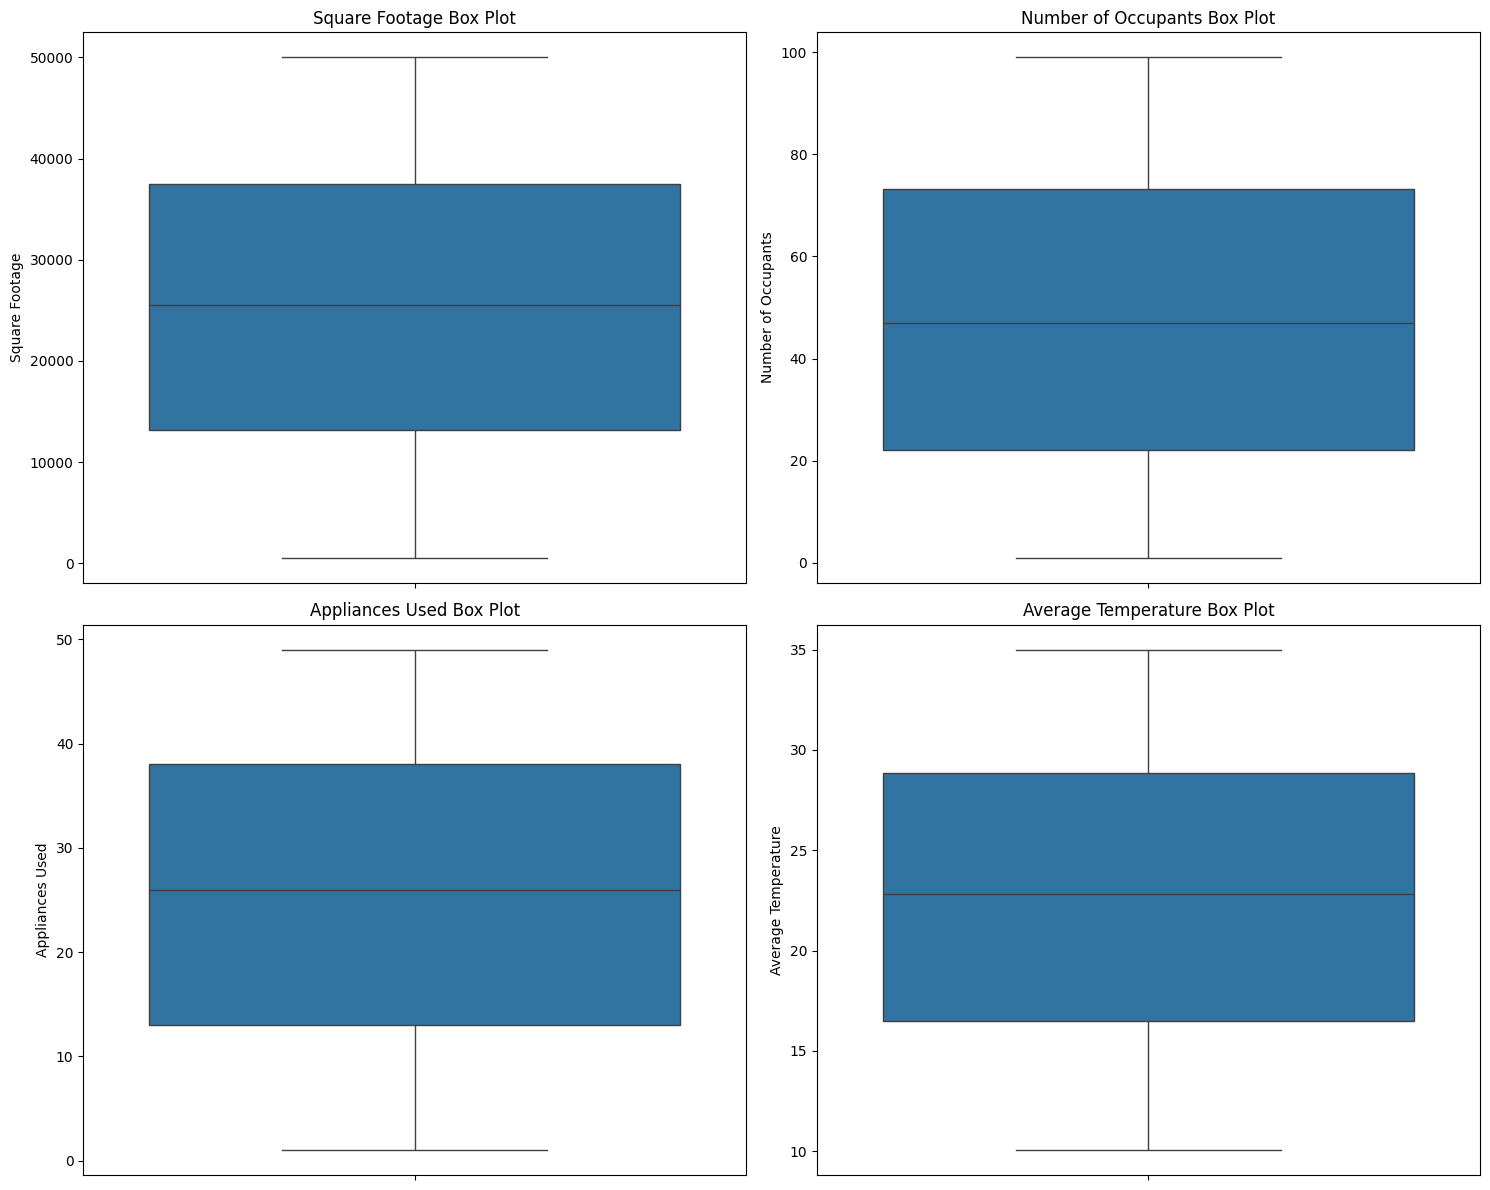

In [13]:
plt.figure(figsize=(15,12))
i=1
for val in numeric:
    plt.subplot(2,2,i)
    sns.boxplot(df[val])
    plt.title(f"{val} Box Plot")
    i+=1
plt.tight_layout()
plt.show()

No outliers detected

In [14]:
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


#### Converting categorical columns into numeric\
Since these categorical values have no inherent order or ranking, we use One Hot Encoding to convert them into numeric features.

In [15]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False,handle_unknown='ignore',dtype=int)
enc_df=pd.DataFrame(ohe.fit_transform(df[['Building Type','Day of Week']]),columns=ohe.get_feature_names_out(),index=df.index)
df.drop(['Building Type','Day of Week'],axis=1,inplace=True)
df=pd.concat([df,enc_df],axis=1)
df.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Building Type_Commercial,Building Type_Industrial,Building Type_Residential,Day of Week_Weekday,Day of Week_Weekend
0,7063,76,10,29.84,2713.95,0,0,1,1,0
1,44372,66,45,16.72,5744.99,1,0,0,1,0
2,19255,37,17,14.30,4101.24,0,1,0,0,1
3,13265,14,41,32.82,3009.14,0,0,1,1,0
4,13375,26,18,11.92,3279.17,1,0,0,1,0


In [16]:
X=df.drop('Energy Consumption',axis=1)
y=df['Energy Consumption']
X.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Building Type_Commercial,Building Type_Industrial,Building Type_Residential,Day of Week_Weekday,Day of Week_Weekend
0,7063,76,10,29.84,0,0,1,1,0
1,44372,66,45,16.72,1,0,0,1,0
2,19255,37,17,14.30,0,1,0,0,1
3,13265,14,41,32.82,0,0,1,1,0
4,13375,26,18,11.92,1,0,0,1,0


In [17]:
y.head()

0    2713.95
1    5744.99
2    4101.24
3    3009.14
4    3279.17
Name: Energy Consumption, dtype: float64

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

#### Feature Scaling

In [19]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred=model.predict(X_test)
y_pred[:5]

array([4549.59824445, 2842.90108278, 5781.84778821, 4773.55057726,
       3791.05021725])

In [22]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("Mean Squared Error= ",mse)
print("Mean Absolute Error= ",mae)
print("Root Mean Squared Error= ",rmse)
print("R2 Score= ",r2)

Mean Squared Error=  0.00018855085579277237
Mean Absolute Error=  0.0114122010775327
Root Mean Squared Error=  0.01373138215158155
R2 Score=  0.9999999997684504


In [23]:
comparison=pd.DataFrame({
    "Actual":y_test.reset_index(drop=True),
    "Predicted": y_pred
})
comparison.head(7)

,Actual,Predicted
0,4549.59,4549.598244
1,2842.91,2842.901083
2,5781.83,5781.847788
3,4773.54,4773.550577
4,3791.04,3791.050217
5,2470.59,2470.599330
6,5003.05,5003.049430


Residuals Plot

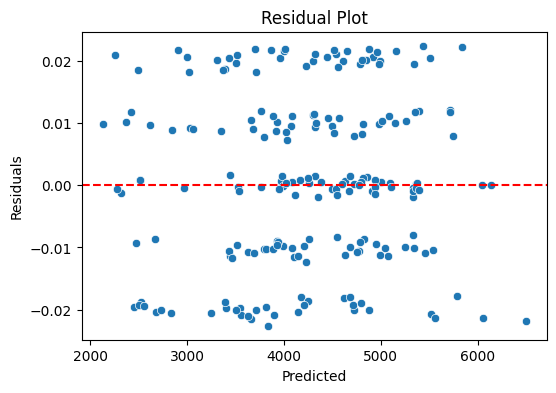

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

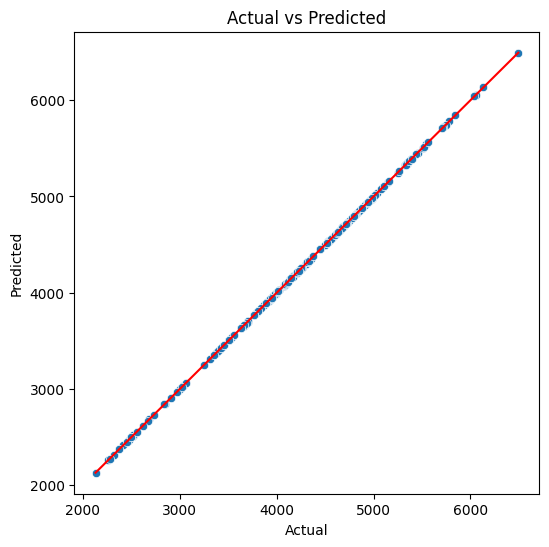

In [25]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [26]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef.sort_values("Coefficient", key=abs, ascending=False)

,Feature,Coefficient
0,Square Footage,719.525884
1,Number of Occupants,293.376265
2,Appliances Used,279.261520
5,Building Type_Industrial,236.606538
6,Building Type_Residential,-234.401992
3,Average Temperature,-35.698239
7,Day of Week_Weekday,12.494649
8,Day of Week_Weekend,-12.494649
4,Building Type_Commercial,4.410309


In [27]:
print(model.intercept_)

4147.9583625


In [28]:
import joblib
joblib.dump(model,"linear_regression_model.pkl")
joblib.dump(ss,"scaler.pkl")

['scaler.pkl']